# **PUC-Rio | Departamento de Engenharia Industrial**
# **ENG 4560: Projeto Integrado VI - Distribuicao Fisica**

---

# **Aula 3 — Modelagem matematica do CVRP (Parte 1)**
**Grupo 2** — Rodrigo Pimentel, Bernardo Caula, Joao Felipe Leal, Lucas Campos, Lucas Terzi

---

## Objetivos

1. **Carregar** uma instancia preparada na Aula 2;
2. **Entender a estrutura** de um modelo de Programacao Linear Inteira (PLI/MIP) no Pyomo;
3. Definir variaveis binarias de roteamento $x_{ij}$;
4. Construir a **funcao objetivo** com custo variavel + custo fixo por veiculo (VUC);
5. Implementar restricoes: visita unica, conservacao de fluxo, balanco no deposito, capacidade agregada;
6. Resolver com solver MIP e **interpretar** resultados;
7. Diagnosticar **subtours** (ciclos desconectados do deposito) — nesta etapa **nao usamos MTZ**.

**Atencao:** ao final deste notebook, uma solucao otima do solver nem sempre representa uma solucao operacionalmente aceitavel. Essa constatacao sera fundamental para a Aula 4.

## Estrutura da Aula Pratica

1. Carregar e validar instancia
2. Definir parametros logisticos
3. Construir modelo matematico em Pyomo
4. Resolver com solver MIP
5. Interpretar solucao
6. Diagnosticar limitacoes estruturais

In [1]:
# ============================================================
# (1) IMPORTS E SELECAO DA INSTANCIA
# ============================================================
# Adaptado para execucao local (Jupyter Lab).
# Os dados foram preparados na Aula 2.
# ============================================================

import numpy as np
import pandas as pd
import json
import os
import time
import matplotlib.pyplot as plt

from pyomo.environ import *
from pyomo.opt import SolverFactory

# ============================================================
# Selecao da instancia a ser analisada
# Altere INSTANCIA para rodar diferentes cenarios.
# ============================================================

INSTANCIA = "Equipe_2_C1_10"   # opcoes: Equipe_2_C1_10, Equipe_2_C2_25, Equipe_2_C3_40, Equipe_2_C4_60

DATA_DIR = os.path.join("..", "2", "datasets", INSTANCIA)

print(f"Instancia selecionada: {INSTANCIA}")
print(f"Diretorio: {DATA_DIR}")
print(f"Arquivos disponiveis: {os.listdir(DATA_DIR)}")

Instancia selecionada: Equipe_2_C1_10
Diretorio: ..\1\datasets\Equipe_2_C1_10
Arquivos disponiveis: ['Cvar.npy', 'D.npy', 'nodes.csv', 'params.json', 'q.npy', 's.npy', 'Tmov_h.npy']


In [2]:
# ============================================================
# (2) LEITURA E VERIFICACAO DOS DADOS
# ============================================================
# Aqui verificamos se os dados carregados fazem sentido. Antes de modelar, garantimos que a instancia esta consistente.
# Modelos MIP sao altamente sensiveis a inconsistencias dimensionais.
# ============================================================

nodes = pd.read_csv(os.path.join(DATA_DIR, "nodes.csv"))
D = np.load(os.path.join(DATA_DIR, "D.npy"))
C = np.load(os.path.join(DATA_DIR, "Cvar.npy"))
q = np.load(os.path.join(DATA_DIR, "q.npy"))
s = np.load(os.path.join(DATA_DIR, "s.npy"))

n = len(nodes)

assert D.shape == (n, n), "Dimensao incorreta de D"
assert C.shape == (n, n), "Dimensao incorreta de C"
assert q.shape == (n,), "Dimensao incorreta de q"
assert s.shape == (n,), "Dimensao incorreta de s"
assert nodes.loc[0, "id"] == 0, "No 0 deve ser o deposito"

print(f"Instancia carregada: {n-1} clientes + deposito")
print(f"Demanda total (kg): {q[1:].sum():.1f}")
print(f"Maior demanda (kg): {q[1:].max():.1f}")

Instancia carregada: 10 clientes + deposito
Demanda total (kg): 141.6
Maior demanda (kg): 53.0


In [3]:
# ============================================================
# (3) PARAMETROS LOGISTICOS
# ============================================================
# Importante: Capacidade e jornada serao modeladas de forma agregada.
# Isso garante viabilidade global, mas NAO garante que cada rota individual respeite capacidade e jornada.
# Nesta aula consideramos tambem frota homogenea (somente VUCs sendo utilizados)
# Essas simplificacoes sao comuns em primeiras modelagens, mas podem esconder limitacoes operacionais reais.
# ============================================================

Q = 3000.0        # Capacidade do VUC (kg) (aqui estamos supondo frota homogenea)
f = 550.0         # Custo fixo por veiculo (R$)
H = 8.0           # Jornada maxima (h)
v_kmh = 40.0      # Velocidade media

T = D / v_kmh

In [4]:
# ============================================================
# (4) CONSTRUCAO DO MODELO
# ============================================================
# Chamamos o Pyomo e criamos a estrutura do modelo de Programacao
# Linear Inteira Mista.
# ============================================================

model = ConcreteModel()

model.N = RangeSet(0, n-1)
model.C = RangeSet(1, n-1)

In [5]:
# ============================================================
# (5) VARIAVEIS DE DECISAO
# ============================================================
# x[i,j] = 1 se o veiculo percorre o arco i -> j;
# Observe: Ainda NAO SABEMOS qual veiculo faz qual rota. Isso sera tratado em aulas futuras.
# Criacao de apenas arcos validos (ou seja, i diferente de j)
# ============================================================

model.A = [(i,j) for i in range(n) for j in range(n) if i != j]
model.x = Var(model.A, domain=Binary)

print(f"Numero de arcos (|A|): {len(model.A)}")
print(f"Variaveis binarias: {len(model.A)}")

Numero de arcos (|A|): 110
Variaveis binarias: 110


In [6]:
# ============================================================
# (6) NUMERO DE VEICULOS UTILIZADOS
# ============================================================
# Criamos uma funcao para determinar o numero de veiculos.
# Aqui estimamos implicitamente quantos veiculos serao necessarios.
# Ainda nao ha identificacao individual de veiculo. Isso pode gerar situacoes inesperadas.
# ============================================================

def m_expr(model):
    return sum(model.x[0,j] for j in model.C)

model.m = Expression(rule=m_expr)

In [7]:
# ============================================================
# (7) FUNCAO OBJETIVO
# ============================================================
# O que significa "otimo"? = Estamos minimizando o custo de deslocamento
# Mas atencao: minimizar distancias nao garante operacao realista.
# ============================================================

def obj_rule(model):
    travel_cost = sum(C[i,j] * model.x[i,j] for (i,j) in model.A)
    fixed_cost = f * model.m
    return travel_cost + fixed_cost

model.obj = Objective(rule=obj_rule, sense=minimize)

In [8]:
# ============================================================
# (8) RESTRICOES
# ============================================================
# As restricoes sao o "coracao" do modelo. Elas informam ao solver o que "nao pode acontecer".
# No nosso caso, ja impedimos ciclos desconectados?
# ============================================================

# Saida unica
def out_rule(model, i):
    return sum(model.x[i,j] for j in model.N if j != i) == 1

model.out_degree = Constraint(model.C, rule=out_rule)

# Entrada unica
def in_rule(model, j):
    return sum(model.x[i,j] for i in model.N if i != j) == 1

model.in_degree = Constraint(model.C, rule=in_rule)

# ============================================================
# Conservacao de fluxo
# OBS: A conservacao de fluxo e redundante quando entrada=1 e saida=1 ja sao impostas.
# Mantemos por clareza estrutural.
# ============================================================

def flow_rule(model, i):
    outflow = sum(model.x[i,j] for j in model.N if j != i)
    inflow  = sum(model.x[j,i] for j in model.N if j != i)
    return outflow - inflow == 0

model.flow = Constraint(model.C, rule=flow_rule)

# Contagem de restricoes
total_restr_aprox = 3 * (n - 1)
print(f"Total aproximado de restricoes ate aqui: {total_restr_aprox}")
print(f"  - out_degree: {n-1}")
print(f"  - in_degree:  {n-1}")
print(f"  - flow:       {n-1}")
print(f"Isso ainda NAO garante conectividade global (ausencia de subtours).")

Total aproximado de restricoes ate aqui: 30
  - out_degree: 10
  - in_degree:  10
  - flow:       10
Isso ainda NAO garante conectividade global (ausencia de subtours).


In [9]:
# ============================================================
# (9) BALANCO NO DEPOSITO
# ============================================================
# Criacao de funcao para garantir saida e retorno ao deposito
# Porem isso nao garante uma unica rota continua.
# ============================================================

def depot_balance(model):
    return sum(model.x[0,j] for j in model.C) == \
           sum(model.x[i,0] for i in model.C)

model.depot_balance = Constraint(rule=depot_balance)

In [10]:
# ============================================================
# (10) CAPACIDADE AGREGADA
# ============================================================
# Criacao de funcao para que a soma das demandas nao exceda a capacidade.
# Ainda estamos tratando capacidade de forma agregada
# Nao sabemos qual veiculo atende qual cliente
# ============================================================

def capacity_rule(model):
    total_demand = sum(q[i] for i in range(1,n))
    return total_demand <= Q * model.m

model.capacity = Constraint(rule=capacity_rule)

In [11]:
# ============================================================
# (11) COMPLEXIDADE
# ============================================================
# O numero de variaveis cresce aproximadamente como n(n-1).
# Isso significa que dobrar clientes pode quadruplicar variaveis.
# ============================================================

print(f"Numero aproximado de variaveis binarias: {len(model.A)}")
print(f"Numero de clientes: {n-1}")

Numero aproximado de variaveis binarias: 110
Numero de clientes: 10


In [12]:
# ============================================================
# (12) ESCOLHA DO SOLVER E RESOLUCAO
# ============================================================
# Utilizamos Gurobi com licenca academica da PUC-Rio.
# Trocar o solver NAO muda o modelo matematico.
# Apenas muda a eficiencia da busca da solucao.
# ============================================================

SOLVER_NAME = "gurobi"

solver = SolverFactory(SOLVER_NAME)

if not solver.available():
    raise RuntimeError(f"O solver {SOLVER_NAME} nao esta disponivel.")

# TimeLimit para evitar travamentos em instancias grandes
try:
    solver.options["TimeLimit"] = 120
except:
    print("Este solver nao aceita a opcao TimeLimit dessa forma.")

print(f"Resolvendo com solver: {SOLVER_NAME}")

start_time = time.time()
results = solver.solve(model, tee=True)
end_time = time.time()

elapsed = end_time - start_time

print(f"\nStatus: {results.solver.status}")
print(f"Termination condition: {results.solver.termination_condition}")
print(f"Tempo de solucao: {elapsed:.2f} segundos")
print(f"Tempo (min): {elapsed/60:.2f}")
print(f"Tempo (h): {elapsed/3600:.3f}")

Resolvendo com solver: gurobi


Read LP format model from file C:\Users\rodri\AppData\Local\Temp\tmpqm0337_s.pyomo.lp
Reading time = 0.01 seconds
x1: 32 rows, 110 columns, 430 nonzeros
Set parameter TimeLimit to value 120


Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-1260P, instruction set [SSE2|AVX|AVX2]
Thread count: 12 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  120

Optimize a model with 32 rows, 110 columns and 430 nonzeros (Min)
Model fingerprint: 0xa2cb396b
Model has 110 linear objective coefficients
Variable types: 0 continuous, 110 integer (110 binary)
Coefficient statistics:
  Matrix range     [1e+00, 3e+03]
  Objective range  [2e-02, 6e+02]
  Bounds range     [1e+00, 1e+00]


  RHS range        [1e+00, 1e+02]

Found heuristic solution: objective 1408.3466500


Presolve removed 10 rows and 0 columns
Presolve time: 0.00s
Presolved: 22 rows, 110 columns, 230 nonzeros


...


    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0     668.7973286  668.79733  0.00%     -    0s



Explored 1 nodes (16 simplex iterations) in 0.01 seconds (0.00 work units)
Thread count was 16 (of 16 available processors)



Solution count 2: 668.797 1408.35 

Optimal solution found (tolerance 1.00e-04)


Best objective 6.687973286131e+02, best bound 6.687973286131e+02, gap 0.0000%



Status: ok
Termination condition: optimal
Tempo de solucao: 0.07 segundos
Tempo (min): 0.00
Tempo (h): 0.000


In [13]:
# ============================================================
# (13) RESULTADOS DO MODELO
# ============================================================
# O solver encontra a solucao otima?
# Uma solucao otima matematicamente significa otima operacionalmente?
# ============================================================

print(f"Custo total: R$ {value(model.obj):.2f}")
print(f"Numero de veiculos utilizados: {int(value(model.m))}")

# Capacidade agregada: demanda total vs capacidade total disponivel
total_demand = sum(q[i] for i in range(1, n))
m_val = value(model.m)
print(f"\nDemanda total: {total_demand:.1f} kg")
print(f"Capacidade total disponivel (Q * m): {Q * m_val:.1f} kg")

Custo total: R$ 668.80
Numero de veiculos utilizados: 1

Demanda total: 141.6 kg
Capacidade total disponivel (Q * m): 3000.0 kg


In [14]:
# ============================================================
# (14) EXTRACAO DOS ARCOS SELECIONADOS
# ============================================================
# Aqui observamos quais conexoes foram escolhidas.
# Mas atencao: ainda nao sabemos se formam rotas validas.
# ============================================================

selected_arcs = [(i,j) for (i,j) in model.A if value(model.x[i,j]) > 0.5]

print(f"Total de arcos selecionados: {len(selected_arcs)}")
print(f"Alguns arcos: {selected_arcs[:20]}")

# Verificacao: o numero total de arcos selecionados deveria ser
# (n-1) arcos de "ida" dos clientes + m arcos saindo do deposito + m arcos voltando ao deposito
# = (n-1) + 2*m  ... mas sem subtour elimination, essa expectativa pode falhar.
print(f"\nEsperado sem subtours: {(n-1) + int(2*value(model.m))} arcos")
print(f"Observado: {len(selected_arcs)} arcos")

Total de arcos selecionados: 11
Alguns arcos: [(0, 5), (1, 7), (2, 8), (3, 9), (4, 10), (5, 0), (6, 4), (7, 1), (8, 2), (9, 3), (10, 6)]

Esperado sem subtours: 12 arcos
Observado: 11 arcos


In [15]:
# ============================================================
# (15) RECONSTRUCAO DAS ROTAS
# ============================================================
# Agora conseguimos visualizar o comportamento emergente do modelo
# ============================================================

succ = {i:j for (i,j) in selected_arcs}

starts = [j for (i,j) in selected_arcs if i == 0]

routes = []

for start in starts:
    route = [0, start]
    current = start
    while current != 0:
        current = succ.get(current, None)
        if current is None:
            break
        route.append(current)
    routes.append(route)

print("Rotas reconstruidas:")
for idx, r in enumerate(routes, 1):
    print(f"  Rota {idx} ({len(r)} nos): {r}")

print(f"\nClientes totais: {n-1}")

visited = set()
for r in routes:
    visited.update(r)
visited.discard(0)

print(f"Clientes atendidos via deposito: {len(visited)}")

Rotas reconstruidas:
  Rota 1 (3 nos): [0, 5, 0]

Clientes totais: 10
Clientes atendidos via deposito: 1


In [16]:
# ============================================================
# (16) CHECAGEM POS-SOLUCAO — JORNADA POR ROTA (VALIDACAO)
# ============================================================
# NAO impusemos jornada no modelo matematico.
# Portanto, apos obter uma solucao, precisamos VALIDAR se cada rota
# respeita ou nao o limite operacional de H horas.
#
# A checagem abaixo e um "pos-processamento" (nao afeta a solucao do solver).
# Ela nos permite comparar: solucao matematica vs. viabilidade operacional.
# ============================================================

def route_time(route):
    # route: lista do tipo [0, ..., 0]
    t_mov = 0.0
    for a in range(len(route)-1):
        i = route[a]
        j = route[a+1]
        t_mov += T[i, j]

    # tempo de servico: soma dos atendimentos dos clientes na rota (exceto deposito)
    clients_in_route = [node for node in route if node != 0]
    t_serv = sum(s[i] for i in clients_in_route)

    return t_mov + t_serv, t_mov, t_serv

print(f"Limite operacional de jornada: H = {H:.2f} h\n")

violations = 0
for r_id, r in enumerate(routes, start=1):
    t_total, t_mov, t_serv = route_time(r)
    status = "OK" if t_total <= H + 1e-6 else "VIOLA"
    if status == "VIOLA":
        violations += 1

    print(f"Rota {r_id}: tempo total = {t_total:.2f} h (mov={t_mov:.2f}, serv={t_serv:.2f}) -> {status}")

print(f"\nTotal de rotas que violam H: {violations}")

Limite operacional de jornada: H = 8.00 h

Rota 1: tempo total = 0.36 h (mov=0.11, serv=0.25) -> OK

Total de rotas que violam H: 0


In [17]:
# ============================================================
# (17) DIAGNOSTICO DE SUBTOURS
# ============================================================
# Caso existam ciclos desconectados ao deposito, isso nao e erro do solver.
# E uma consequencia direta da formulacao do modelo matematico empregado aqui.
# ============================================================

unvisited = set(range(n))
subtours = []

while unvisited:
    node = next(iter(unvisited))
    cycle = []
    current = node
    while current in unvisited:
        unvisited.remove(current)
        cycle.append(current)
        current = succ.get(current, None)
        if current is None:
            break
    if cycle:
        subtours.append(cycle)

sub_no_depot = [c for c in subtours if 0 not in c and len(c) > 1]

if sub_no_depot:
    print(f"Subtours encontrados: {len(sub_no_depot)}")
    for idx, st in enumerate(sub_no_depot, 1):
        print(f"  Subtour {idx} (tamanho {len(st)}): {st}")
else:
    print("Nenhum subtour detectado.")

Subtours encontrados: 4
  Subtour 1 (tamanho 2): [1, 7]
  Subtour 2 (tamanho 2): [2, 8]
  Subtour 3 (tamanho 2): [3, 9]
  Subtour 4 (tamanho 3): [4, 10, 6]


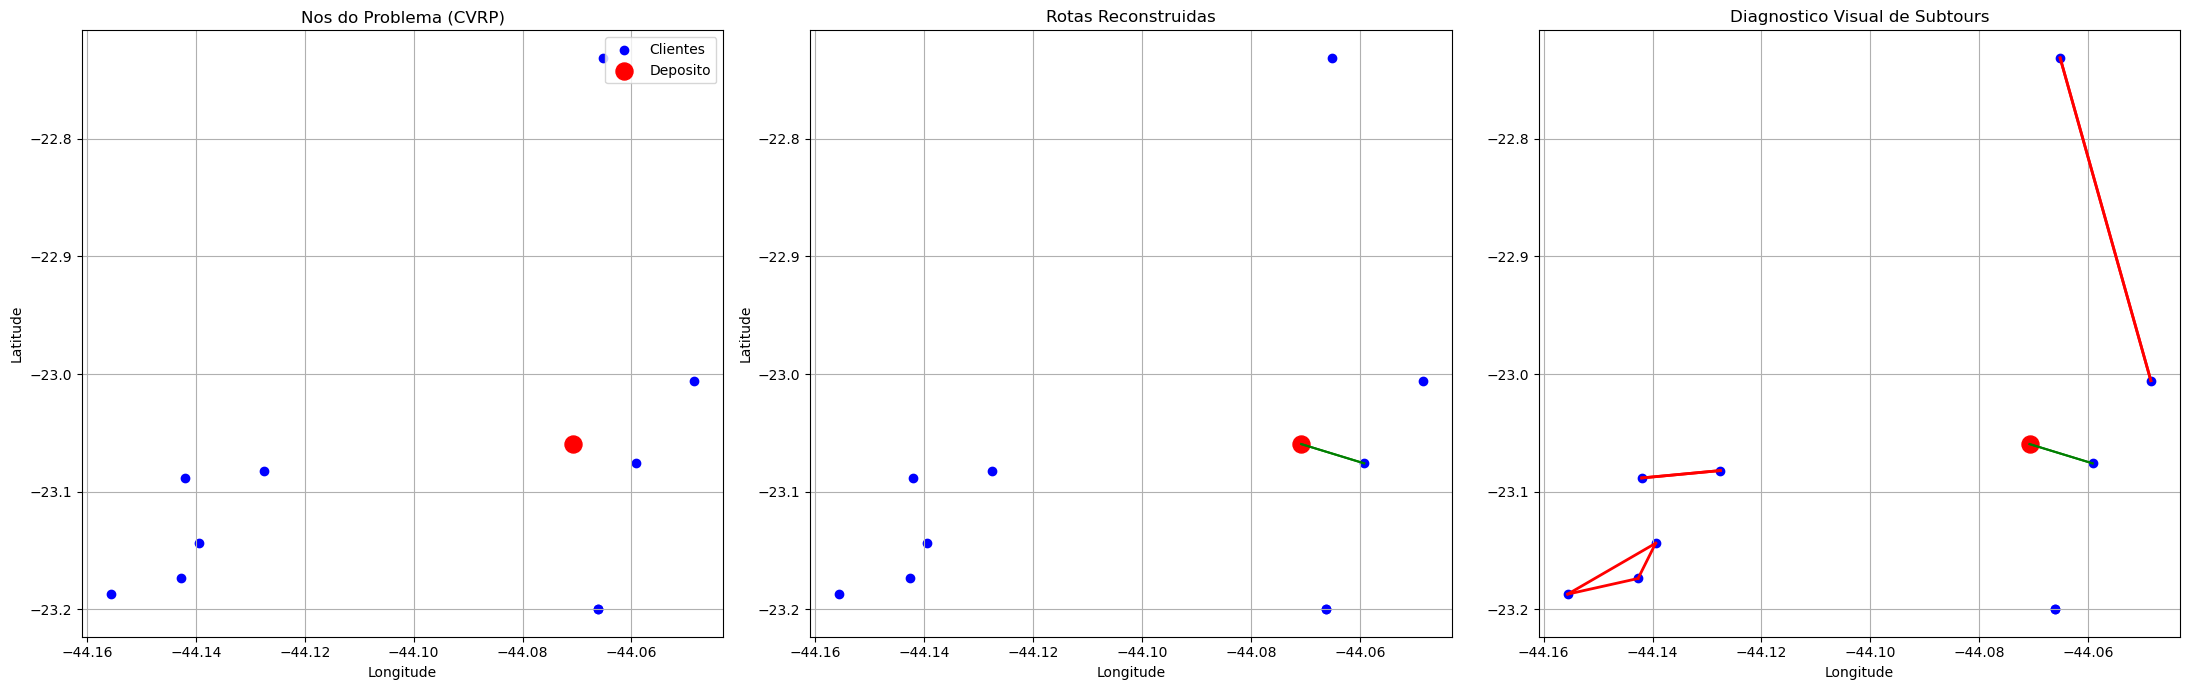

In [18]:
# ============================================================
# (18) VISUALIZACAO DAS ROTAS E SUBTOURS (caso existam)
# ============================================================
# Observe cuidadosamente o mapa.
# Existem rotas que nao passam pelo deposito/CD?
# ============================================================

x_coords = nodes["lon"].values
y_coords = nodes["lat"].values

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# --- Grafico 1: Nos do problema ---
ax = axes[0]
ax.scatter(x_coords[1:], y_coords[1:], color='blue', label='Clientes')
ax.scatter(x_coords[0], y_coords[0], color='red', s=150, label='Deposito')
ax.set_title("Nos do Problema (CVRP)")
ax.legend()
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

# --- Grafico 2: Rotas reconstruidas ---
ax = axes[1]
ax.scatter(x_coords[1:], y_coords[1:], color='blue')
ax.scatter(x_coords[0], y_coords[0], color='red', s=150)
for route in routes:
    for i in range(len(route)-1):
        i_node = route[i]
        j_node = route[i+1]
        ax.plot([x_coords[i_node], x_coords[j_node]],
                [y_coords[i_node], y_coords[j_node]],
                color='green')
ax.set_title("Rotas Reconstruidas")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True)

# --- Grafico 3: Diagnostico de subtours ---
ax = axes[2]
ax.scatter(x_coords[1:], y_coords[1:], color='blue')
ax.scatter(x_coords[0], y_coords[0], color='red', s=150)
for route in routes:
    for i in range(len(route)-1):
        i_node = route[i]
        j_node = route[i+1]
        ax.plot([x_coords[i_node], x_coords[j_node]],
                [y_coords[i_node], y_coords[j_node]],
                color='green')
for cycle in sub_no_depot:
    for i in range(len(cycle)):
        i_node = cycle[i]
        j_node = cycle[(i+1) % len(cycle)]
        ax.plot([x_coords[i_node], x_coords[j_node]],
                [y_coords[i_node], y_coords[j_node]],
                color='red', linewidth=2)
ax.set_title("Diagnostico Visual de Subtours")
ax.set_xlabel("Longitude")
ax.grid(True)

plt.tight_layout()
plt.show()

## Perguntas para reflexao (Aula 3)

1. **O solver errou ou seguiu exatamente o que formulamos/pedimos?**

O solver seguiu exatamente a formulacao. Ele minimizou a funcao objetivo sujeita as restricoes impostas. Se subtours apareceram, e porque a formulacao nao os proibia — nao e erro do solver, e incompletude do modelo.

2. **O modelo matematico representa completamente a operacao logistica?**

Nao. O modelo usa capacidade e jornada agregadas, sem identificacao individual de veiculos. Alem disso, nao ha restricao de eliminacao de subtours. A solucao pode conter ciclos desconectados do deposito e rotas que violam a jornada maxima.

3. **Qual restricao parece estar faltando?**

Restricoes de eliminacao de subtours (como MTZ — Miller-Tucker-Zemlin). Sem elas, o modelo permite ciclos entre clientes que nao passam pelo deposito.

4. **Como poderiamos impedir ciclos desconectados?**

Adicionando restricoes de subtour elimination. As abordagens classicas sao: (a) restricoes MTZ com variaveis auxiliares de ordem $u_i$; (b) restricoes de corte (SEC — Subtour Elimination Constraints) adicionadas iterativamente. A Aula 4 trata disso.

5. **Capacidade e jornada agregadas vs. individuais: vantagens e desvantagens?**

- **Agregadas** (como neste modelo): formulacao mais simples, menos variaveis, solver mais rapido. Porem nao garante viabilidade operacional por rota — uma rota individual pode ultrapassar capacidade ou jornada.
- **Individuais**: cada veiculo tem suas proprias restricoes, garantindo viabilidade rota a rota. Porem requer identificacao explicita dos veiculos (indice $k$), aumentando significativamente o numero de variaveis ($x_{ijk}$ em vez de $x_{ij}$).

---

## Experimentos computacionais — Todas as instancias (C1 a C4)

A celula abaixo executa o modelo MILP para as 4 instancias e consolida os resultados em uma tabela comparativa.

In [ ]:
# ============================================================
# (19) EXECUCAO PARA TODAS AS INSTANCIAS
# ============================================================

INSTANCIAS = [
    "Equipe_2_C1_10",
    "Equipe_2_C2_25",
    "Equipe_2_C3_40",
    "Equipe_2_C4_60",
]

Q_vuc = 3000.0
f_vuc = 550.0
H_max = 8.0
v_media = 40.0

resultados = []

for inst_name in INSTANCIAS:
    print(f"\n{'='*60}")
    print(f"Instancia: {inst_name}")
    print(f"{'='*60}")

    # Carregar dados
    ddir = os.path.join("..", "2", "datasets", inst_name)
    nd = pd.read_csv(os.path.join(ddir, "nodes.csv"))
    Dd = np.load(os.path.join(ddir, "D.npy"))
    Cd = np.load(os.path.join(ddir, "Cvar.npy"))
    qd = np.load(os.path.join(ddir, "q.npy"))
    sd = np.load(os.path.join(ddir, "s.npy"))
    Td = Dd / v_media
    nn = len(nd)

    # Construir modelo
    mdl = ConcreteModel()
    mdl.N = RangeSet(0, nn-1)
    mdl.C = RangeSet(1, nn-1)
    mdl.A = [(i,j) for i in range(nn) for j in range(nn) if i != j]
    mdl.x = Var(mdl.A, domain=Binary)

    def m_expr_loop(mdl):
        return sum(mdl.x[0,j] for j in mdl.C)
    mdl.m = Expression(rule=m_expr_loop)

    def obj_rule_loop(mdl):
        travel_cost = sum(Cd[i,j] * mdl.x[i,j] for (i,j) in mdl.A)
        fixed_cost = f_vuc * mdl.m
        return travel_cost + fixed_cost
    mdl.obj = Objective(rule=obj_rule_loop, sense=minimize)

    def out_rule_loop(mdl, i):
        return sum(mdl.x[i,j] for j in mdl.N if j != i) == 1
    mdl.out_degree = Constraint(mdl.C, rule=out_rule_loop)

    def in_rule_loop(mdl, j):
        return sum(mdl.x[i,j] for i in mdl.N if i != j) == 1
    mdl.in_degree = Constraint(mdl.C, rule=in_rule_loop)

    def flow_rule_loop(mdl, i):
        outflow = sum(mdl.x[i,j] for j in mdl.N if j != i)
        inflow  = sum(mdl.x[j,i] for j in mdl.N if j != i)
        return outflow - inflow == 0
    mdl.flow = Constraint(mdl.C, rule=flow_rule_loop)

    def depot_balance_loop(mdl):
        return sum(mdl.x[0,j] for j in mdl.C) == sum(mdl.x[i,0] for i in mdl.C)
    mdl.depot_balance = Constraint(rule=depot_balance_loop)

    def capacity_rule_loop(mdl):
        total_demand = sum(qd[i] for i in range(1, nn))
        return total_demand <= Q_vuc * mdl.m
    mdl.capacity = Constraint(rule=capacity_rule_loop)

    # Resolver
    slv = SolverFactory("gurobi")
    slv.options["TimeLimit"] = 120

    t0 = time.time()
    res = slv.solve(mdl)
    t1 = time.time()
    elapsed_s = t1 - t0

    status = str(res.solver.termination_condition)
    custo = value(mdl.obj)
    m_veiculos = int(value(mdl.m))

    # Extrair arcos e rotas
    sel_arcs = [(i,j) for (i,j) in mdl.A if value(mdl.x[i,j]) > 0.5]
    suc = {i:j for (i,j) in sel_arcs}
    strt = [j for (i,j) in sel_arcs if i == 0]

    rts = []
    for s_node in strt:
        rt = [0, s_node]
        cur = s_node
        while cur != 0:
            cur = suc.get(cur, None)
            if cur is None:
                break
            rt.append(cur)
        rts.append(rt)

    # Subtours
    unvis = set(range(nn))
    subs = []
    while unvis:
        node = next(iter(unvis))
        cyc = []
        cur = node
        while cur in unvis:
            unvis.remove(cur)
            cyc.append(cur)
            cur = suc.get(cur, None)
            if cur is None:
                break
        if cyc:
            subs.append(cyc)
    sub_nd = [c for c in subs if 0 not in c and len(c) > 1]

    # Jornada
    n_viola = 0
    for rt in rts:
        t_m = sum(Td[rt[a], rt[a+1]] for a in range(len(rt)-1))
        t_s = sum(sd[node] for node in rt if node != 0)
        if t_m + t_s > H_max + 1e-6:
            n_viola += 1

    # Clientes atendidos via deposito
    vis = set()
    for rt in rts:
        vis.update(rt)
    vis.discard(0)

    resultados.append({
        "Instancia": inst_name,
        "Clientes": nn - 1,
        "Demanda (kg)": round(qd[1:].sum(), 1),
        "Custo total (R$)": round(custo, 2),
        "Veiculos (m)": m_veiculos,
        "Rotas via deposito": len(rts),
        "Clientes atendidos": len(vis),
        "Subtours": len(sub_nd),
        "Violacoes jornada": n_viola,
        "Tempo (s)": round(elapsed_s, 2),
        "Status": status,
    })

    print(f"  Custo: R$ {custo:.2f} | Veiculos: {m_veiculos} | Subtours: {len(sub_nd)} | Tempo: {elapsed_s:.2f}s")

# Tabela comparativa
df_resultados = pd.DataFrame(resultados)
print("\n" + "="*60)
print("TABELA COMPARATIVA — METODO EXATO (SEM MTZ)")
print("="*60)
df_resultados